In [1]:
# ============================================================================
# ПОДГОТОВИТЕЛЬНАЯ ЧАСТЬ: Импорт библиотек и загрузка данных
# 准备部分：导入库和加载数据
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_regression
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

%matplotlib inline

# Настройка стиля графиков (только английский + русский)
# 设置图表样式（只用英文+俄语）
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ")
print("所有库已成功加载")
print("=" * 60)

# Загрузка датасета California Housing
# 加载加州房价数据集
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print("\n" + "=" * 60)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ CALIFORNIA HOUSING")
print("加州房价数据集信息")
print("=" * 60)

print(f"\nРазмер датасета / 数据集大小: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"\nПризнаки / 特征:")
for i, name in enumerate(housing.feature_names):
    print(f"  {i+1}. {name}")
print(f"\nЦелевая переменная / 目标变量: target (стоимость дома / 房价)")

print("\n" + "-" * 60)
print("ПЕРВЫЕ 5 СТРОК / 前5行数据")
print("-" * 60)
df.head()

БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ
所有库已成功加载

ИНФОРМАЦИЯ О ДАТАСЕТЕ CALIFORNIA HOUSING
加州房价数据集信息

Размер датасета / 数据集大小: 20640 строк × 9 столбцов

Признаки / 特征:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

Целевая переменная / 目标变量: target (стоимость дома / 房价)

------------------------------------------------------------
ПЕРВЫЕ 5 СТРОК / 前5行数据
------------------------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# ============================================================================
# ОБЩИЙ АНАЛИЗ ДАННЫХ
# 数据总体分析
# ============================================================================

print("=" * 60)
print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ДАННЫХ")
print("数据统计描述")
print("=" * 60)

print("\n【ОПИСАНИЕ ПРИЗНАКОВ / 特征描述】")
print(df.describe())

print("\n" + "-" * 60)
print("ПРОВЕРКА НАЛИЧИЯ ПРОПУСКОВ / 检查缺失值")
print("-" * 60)
print(df.isnull().sum())

print("\n✓ В датасете нет пропусков / 数据集中没有缺失值")

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ДАННЫХ
数据统计描述

【ОПИСАНИЕ ПРИЗНАКОВ / 特征描述】
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.13

ЗАДАЧА 1: МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
TASK 1: FEATURE SCALING

Выбранный признак / 选中的特征: 'MedInc' (MedInc)
До масштабирования / 缩放前:
  min = 0.4999, max = 15.0001
  mean = 3.8707, std = 1.8998

------------------------------------------------------------
【1.1】MIN-MAX SCALING [0, 1]
------------------------------------------------------------
  После Min-Max / Min-Max后:
    min = 0.0000, max = 1.0000
    mean = 0.2325, std = 0.1310

------------------------------------------------------------
【1.2】STANDARD SCALING (Z-SCORE)
------------------------------------------------------------
  После Standard Scaling / 标准化后:
    min = -1.7743, max = 5.8583
    mean = 0.0000, std = 1.0000

------------------------------------------------------------
【1.3】ROBUST SCALING (median + IQR)
------------------------------------------------------------
  После Robust Scaling / Robust缩放后:
    min = -1.3923, max = 5.2597
    mean = 0.1541, std = 0.8715

-------------------------------------------------------

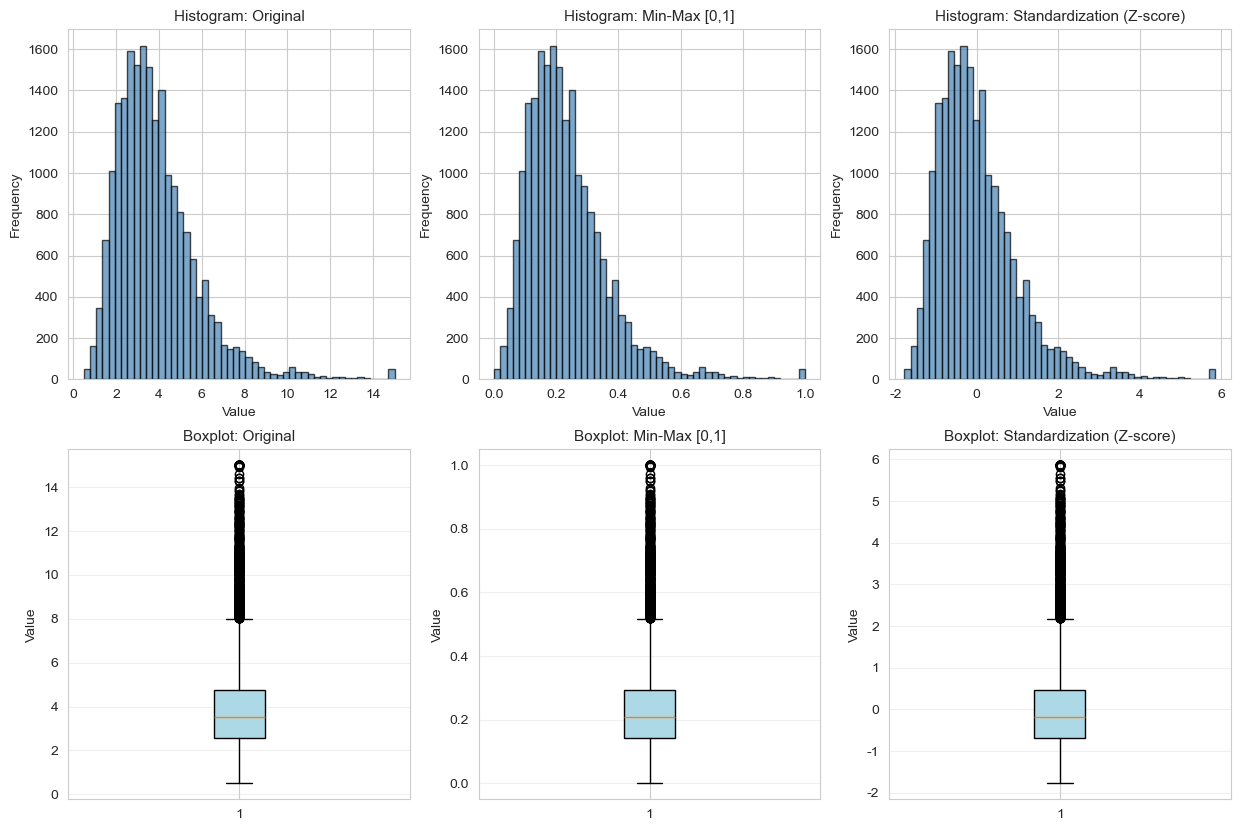

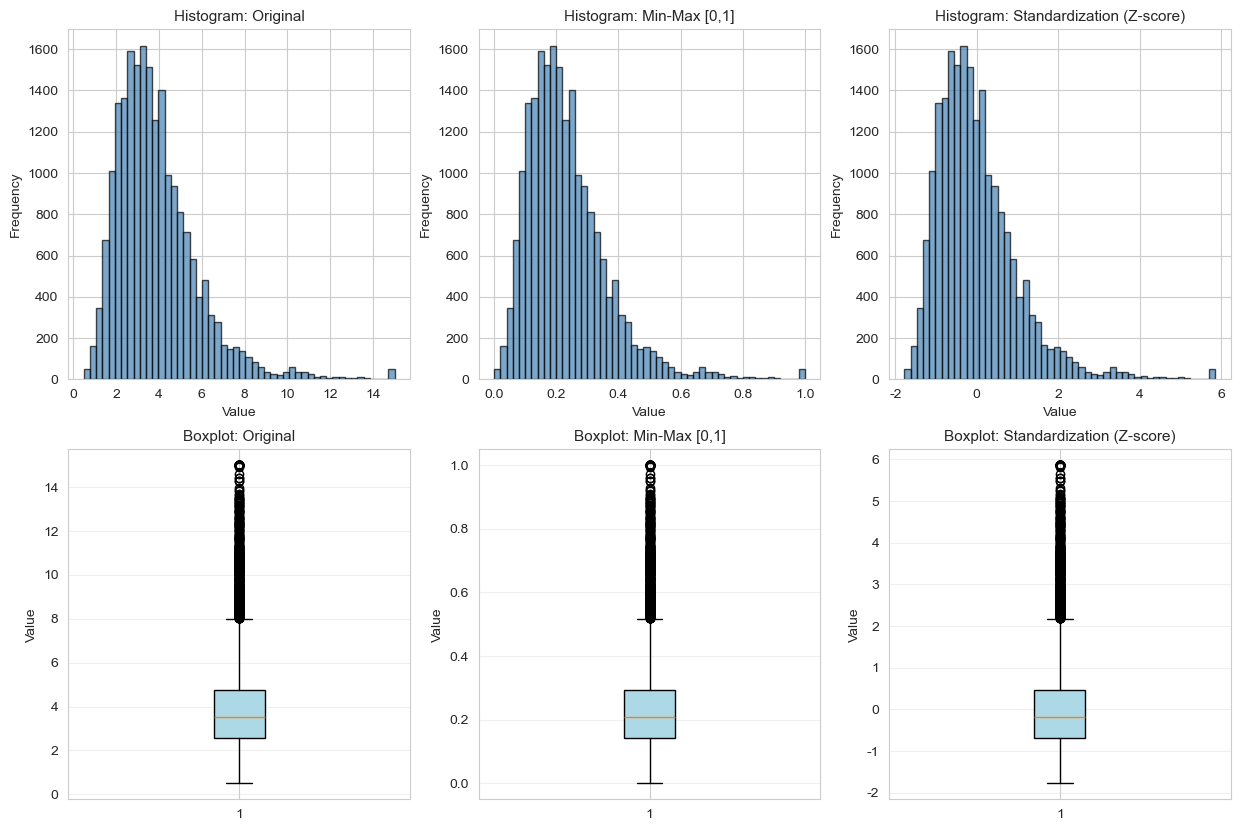

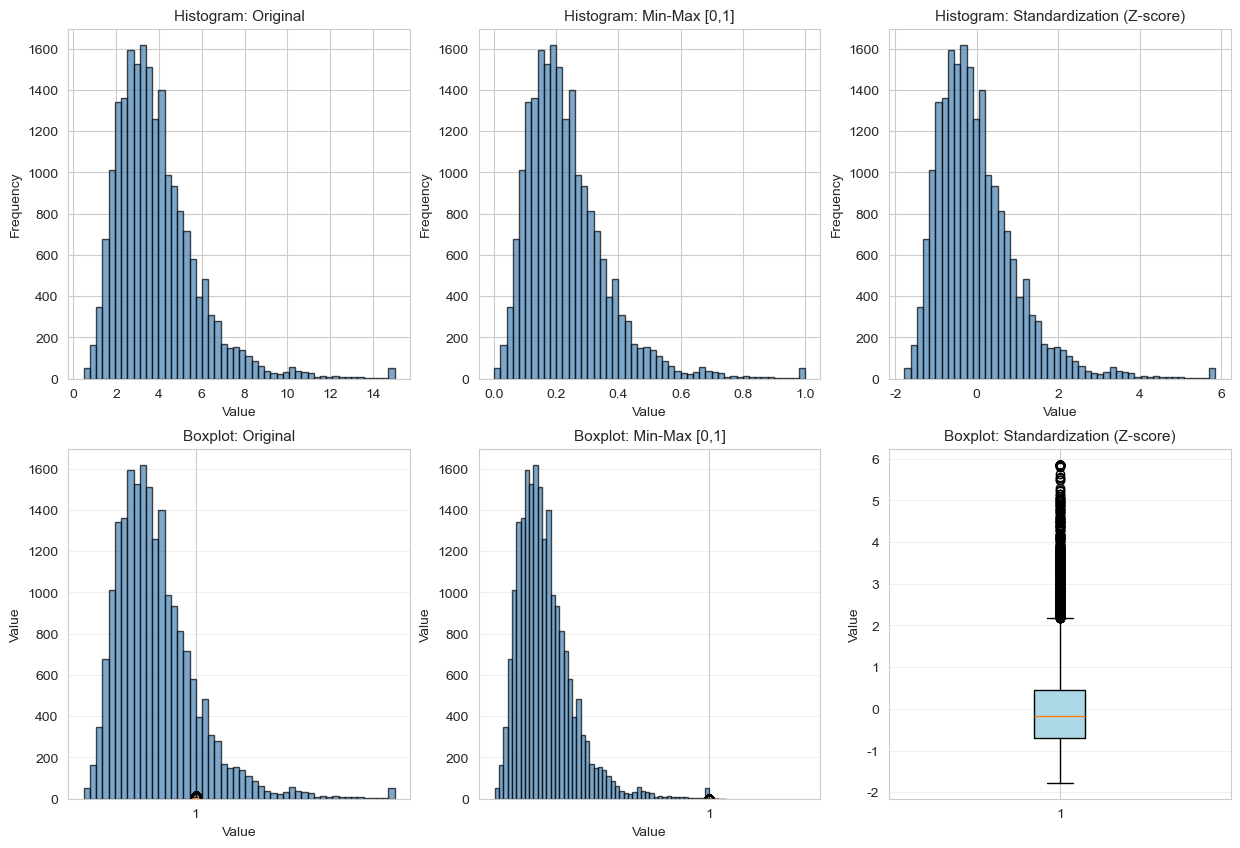

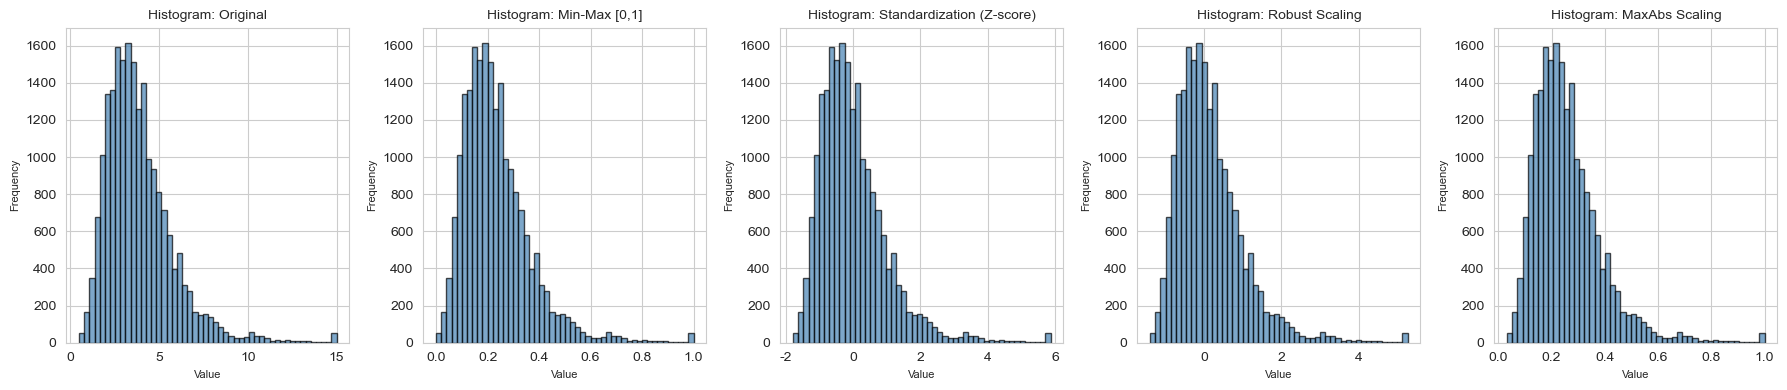

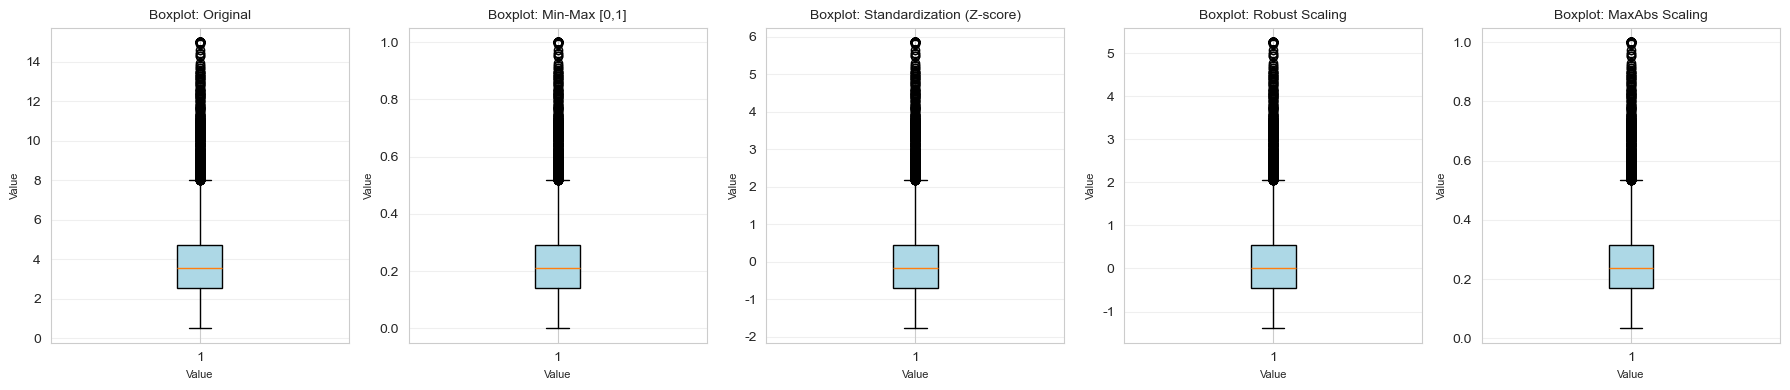


СВОДНАЯ ТАБЛИЦА МЕТОДОВ МАСШТАБИРОВАНИЯ
缩放方法汇总表
  Method       Min       Max         Mean      Std
Original  0.499900 15.000100 3.870671e+00 1.899822
 Min-Max  0.000000  1.000000 2.324638e-01 0.131020
Standard -1.774299  5.858286 6.609700e-17 1.000024
  Robust -1.392252  5.259674 1.540799e-01 0.871538
  MaxAbs  0.033326  1.000000 2.580430e-01 0.126654

✓ TASK 1 COMPLETED / ЗАДАЧА 1 ВЫПОЛНЕНА!


In [6]:
# ============================================================================
# ЗАДАЧА 1: МАСШТАБИРОВАНИЕ ПРИЗНАКОВ (4 способа) - ИСПРАВЛЕННАЯ ВЕРСИЯ 2
# TASK 1: FEATURE SCALING (4 methods) - CORRECTED VERSION 2
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 1: МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
print("TASK 1: FEATURE SCALING")
print("=" * 60)

# Выбираем числовой признак для демонстрации
# 选择数值特征进行演示
feature_name = 'MedInc'
X_feature = df[[feature_name]].copy()

print(f"\nВыбранный признак / 选中的特征: '{feature_name}' (MedInc)")
print(f"До масштабирования / 缩放前:")
print(f"  min = {X_feature.min().values[0]:.4f}, max = {X_feature.max().values[0]:.4f}")
print(f"  mean = {X_feature.mean().values[0]:.4f}, std = {X_feature.std().values[0]:.4f}")

# ============================================================================
# 1.1 Min-Max Scaling [0, 1]
# ============================================================================

print("\n" + "-" * 60)
print("【1.1】MIN-MAX SCALING [0, 1]")
print("-" * 60)

scaler_minmax = MinMaxScaler()
df['MedInc_minmax'] = scaler_minmax.fit_transform(X_feature)

print(f"  После Min-Max / Min-Max后:")
print(f"    min = {df['MedInc_minmax'].min():.4f}, max = {df['MedInc_minmax'].max():.4f}")
print(f"    mean = {df['MedInc_minmax'].mean():.4f}, std = {df['MedInc_minmax'].std():.4f}")

# ============================================================================
# 1.2 Standard Scaling (Z-score)
# ============================================================================

print("\n" + "-" * 60)
print("【1.2】STANDARD SCALING (Z-SCORE)")
print("-" * 60)

scaler_std = StandardScaler()
df['MedInc_standard'] = scaler_std.fit_transform(X_feature)

print(f"  После Standard Scaling / 标准化后:")
print(f"    min = {df['MedInc_standard'].min():.4f}, max = {df['MedInc_standard'].max():.4f}")
print(f"    mean = {df['MedInc_standard'].mean():.4f}, std = {df['MedInc_standard'].std():.4f}")

# ============================================================================
# 1.3 Robust Scaling
# ============================================================================

print("\n" + "-" * 60)
print("【1.3】ROBUST SCALING (median + IQR)")
print("-" * 60)

scaler_robust = RobustScaler()
df['MedInc_robust'] = scaler_robust.fit_transform(X_feature)

print(f"  После Robust Scaling / Robust缩放后:")
print(f"    min = {df['MedInc_robust'].min():.4f}, max = {df['MedInc_robust'].max():.4f}")
print(f"    mean = {df['MedInc_robust'].mean():.4f}, std = {df['MedInc_robust'].std():.4f}")

# ============================================================================
# 1.4 MaxAbs Scaling
# ============================================================================

print("\n" + "-" * 60)
print("【1.4】MAXABS SCALING")
print("-" * 60)

scaler_maxabs = MaxAbsScaler()
df['MedInc_maxabs'] = scaler_maxabs.fit_transform(X_feature)

print(f"  После MaxAbs Scaling / MaxAbs缩放后:")
print(f"    min = {df['MedInc_maxabs'].min():.4f}, max = {df['MedInc_maxabs'].max():.4f}")
print(f"    mean = {df['MedInc_maxabs'].mean():.4f}, std = {df['MedInc_maxabs'].std():.4f}")

# ============================================================================
# 1.5 Визуализация результатов масштабирования (два отдельных графика)
# 缩放结果可视化（两个独立的图形）
# ============================================================================

print("\n" + "-" * 60)
print("【1.5】ВИЗУАЛИЗАЦИЯ / VISUALIZATION")
print("-" * 60)

# Список признаков для визуализации
# 需要可视化的特征列表
features_to_plot = ['MedInc', 'MedInc_minmax', 'MedInc_standard', 'MedInc_robust', 'MedInc_maxabs']
titles = ['Original', 'Min-Max [0,1]', 'Standardization (Z-score)', 'Robust Scaling', 'MaxAbs Scaling']

# ========== ГРАФИК 1: ГИСТОГРАММЫ (5 столбцов в одном ряду) ==========
# 图1：直方图（一行5列）
fig1, axes1 = plt.subplots(1, 5, figsize=(18, 4))

for i, (feature, title) in enumerate(zip(features_to_plot, titles)):
    axes1[i].hist(df[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes1[i].set_title(f'Histogram: {title}', fontsize=10)
    axes1[i].set_xlabel('Value', fontsize=8)
    axes1[i].set_ylabel('Frequency', fontsize=8)

plt.tight_layout()
plt.show()

# ========== ГРАФИК 2: БОКСПЛОТЫ (5 столбцов в одном ряду) ==========
# 图2：箱线图（一行5列）
fig2, axes2 = plt.subplots(1, 5, figsize=(18, 4))

for i, (feature, title) in enumerate(zip(features_to_plot, titles)):
    axes2[i].boxplot(df[feature], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
    axes2[i].set_title(f'Boxplot: {title}', fontsize=10)
    axes2[i].set_xlabel('Value', fontsize=8)
    axes2[i].set_ylabel('Value', fontsize=8)
    axes2[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Сводная таблица
# ============================================================================

print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА МЕТОДОВ МАСШТАБИРОВАНИЯ")
print("缩放方法汇总表")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Method': ['Original', 'Min-Max', 'Standard', 'Robust', 'MaxAbs'],
    'Min': [
        df['MedInc'].min(),
        df['MedInc_minmax'].min(),
        df['MedInc_standard'].min(),
        df['MedInc_robust'].min(),
        df['MedInc_maxabs'].min()
    ],
    'Max': [
        df['MedInc'].max(),
        df['MedInc_minmax'].max(),
        df['MedInc_standard'].max(),
        df['MedInc_robust'].max(),
        df['MedInc_maxabs'].max()
    ],
    'Mean': [
        df['MedInc'].mean(),
        df['MedInc_minmax'].mean(),
        df['MedInc_standard'].mean(),
        df['MedInc_robust'].mean(),
        df['MedInc_maxabs'].mean()
    ],
    'Std': [
        df['MedInc'].std(),
        df['MedInc_minmax'].std(),
        df['MedInc_standard'].std(),
        df['MedInc_robust'].std(),
        df['MedInc_maxabs'].std()
    ]
})

print(comparison_df.to_string(index=False))

print("\n✓ TASK 1 COMPLETED / ЗАДАЧА 1 ВЫПОЛНЕНА!")

ЗАДАЧА 2: ОБРАБОТКА ВЫБРОСОВ
TASK 2: OUTLIER DETECTION AND HANDLING

Выбранный признак / 选中的特征: 'AveRooms'
До обработки / 处理前:
  min = 0.85, max = 141.91
  mean = 5.43, std = 2.47

------------------------------------------------------------
【2.1】ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR
使用 IQR 方法检测异常值
------------------------------------------------------------
  Q1 (25% квартиль / 25%分位数): 4.44
  Q3 (75% квартиль / 75%分位数): 6.05
  IQR (межквартильный размах / 四分位距): 1.61
  Нижняя граница / 下界: 2.02
  Верхняя граница / 上界: 8.47

  Количество выбросов / 异常值数量: 511 (2.48%)

------------------------------------------------------------
【2.2】УДАЛЕНИЕ ВЫБРОСОВ / DELETING OUTLIERS
------------------------------------------------------------
  Размер до удаления / 删除前大小: 20640
  Размер после удаления / 删除后大小: 20129
  Удалено записей / 删除记录数: 511

  Статистика после УДАЛЕНИЯ / 删除后的统计:
    min = 2.03
    max = 8.47
    mean = 5.24

------------------------------------------------------------
【2.3】ЗАМЕНА

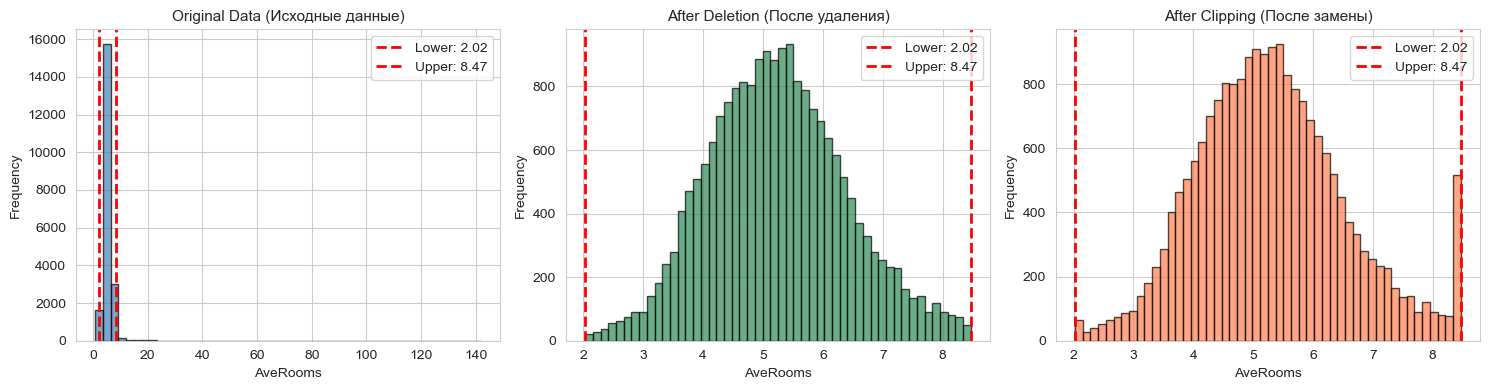


РЕЗУЛЬТАТЫ ОБРАБОТКИ ВЫБРОСОВ / OUTLIER HANDLING RESULTS
  IQR метод: Q1=4.44, Q3=6.05, IQR=1.61
  Границы / 边界: [2.02, 8.47]
  Найдено выбросов / 找到异常值: 511 (2.48%)
  Удаление: 20640 -> 20129 (удалено 511)
  Замена: min стал 2.02, max стал 8.47

✓ TASK 2 COMPLETED / ЗАДАЧА 2 ВЫПОЛНЕНА!


In [7]:
# ============================================================================
# ЗАДАЧА 2: ОБРАБОТКА ВЫБРОСОВ
# TASK 2: OUTLIER DETECTION AND HANDLING
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 2: ОБРАБОТКА ВЫБРОСОВ")
print("TASK 2: OUTLIER DETECTION AND HANDLING")
print("=" * 60)

# Выбираем признак для анализа выбросов
# 选择用于异常值分析的特征
outlier_feature = 'AveRooms'  # Среднее количество комнат / 平均房间数

print(f"\nВыбранный признак / 选中的特征: '{outlier_feature}'")
print(f"До обработки / 处理前:")
print(f"  min = {df[outlier_feature].min():.2f}, max = {df[outlier_feature].max():.2f}")
print(f"  mean = {df[outlier_feature].mean():.2f}, std = {df[outlier_feature].std():.2f}")

# ============================================================================
# 2.1 Обнаружение выбросов методом межквартильного размаха (IQR)
# 使用 IQR（四分位距）方法检测异常值
# ============================================================================

print("\n" + "-" * 60)
print("【2.1】ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR")
print("使用 IQR 方法检测异常值")
print("-" * 60)

Q1 = df[outlier_feature].quantile(0.25)
Q3 = df[outlier_feature].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"  Q1 (25% квартиль / 25%分位数): {Q1:.2f}")
print(f"  Q3 (75% квартиль / 75%分位数): {Q3:.2f}")
print(f"  IQR (межквартильный размах / 四分位距): {IQR:.2f}")
print(f"  Нижняя граница / 下界: {lower_bound:.2f}")
print(f"  Верхняя граница / 上界: {upper_bound:.2f}")

outliers = df[(df[outlier_feature] < lower_bound) | (df[outlier_feature] > upper_bound)]
print(f"\n  Количество выбросов / 异常值数量: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# ============================================================================
# 2.2 Удаление выбросов / 删除异常值
# ============================================================================

print("\n" + "-" * 60)
print("【2.2】УДАЛЕНИЕ ВЫБРОСОВ / DELETING OUTLIERS")
print("-" * 60)

df_no_outliers = df[(df[outlier_feature] >= lower_bound) & (df[outlier_feature] <= upper_bound)].copy()

print(f"  Размер до удаления / 删除前大小: {len(df)}")
print(f"  Размер после удаления / 删除后大小: {len(df_no_outliers)}")
print(f"  Удалено записей / 删除记录数: {len(df) - len(df_no_outliers)}")

print(f"\n  Статистика после УДАЛЕНИЯ / 删除后的统计:")
print(f"    min = {df_no_outliers[outlier_feature].min():.2f}")
print(f"    max = {df_no_outliers[outlier_feature].max():.2f}")
print(f"    mean = {df_no_outliers[outlier_feature].mean():.2f}")

# ============================================================================
# 2.3 Замена выбросов граничными значениями (Clipping)
# 用边界值替换异常值（裁剪）
# ============================================================================

print("\n" + "-" * 60)
print("【2.3】ЗАМЕНА ВЫБРОСОВ ГРАНИЧНЫМИ ЗНАЧЕНИЯМИ (CLIPPING)")
print("用边界值替换异常值（裁剪）")
print("-" * 60)

df_clipped = df.copy()
df_clipped[outlier_feature + '_clipped'] = df_clipped[outlier_feature].clip(lower=lower_bound, upper=upper_bound)

print(f"  Статистика после ЗАМЕНЫ / 替换后的统计:")
print(f"    min = {df_clipped[outlier_feature + '_clipped'].min():.2f}")
print(f"    max = {df_clipped[outlier_feature + '_clipped'].max():.2f}")
print(f"    mean = {df_clipped[outlier_feature + '_clipped'].mean():.2f}")

# ============================================================================
# 2.4 Простая визуализация (если matplotlib работает)
# 简单可视化（如果matplotlib可用）
# ============================================================================

print("\n" + "-" * 60)
print("【2.4】ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (опционально)")
print("结果可视化（可选）")
print("-" * 60)

try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Original
    axes[0].hist(df[outlier_feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(lower_bound, color='red', linestyle='dashed', linewidth=2, label=f'Lower: {lower_bound:.2f}')
    axes[0].axvline(upper_bound, color='red', linestyle='dashed', linewidth=2, label=f'Upper: {upper_bound:.2f}')
    axes[0].set_title('Original Data (Исходные данные)', fontsize=11)
    axes[0].set_xlabel('AveRooms', fontsize=10)
    axes[0].set_ylabel('Frequency', fontsize=10)
    axes[0].legend()

    # After deletion
    axes[1].hist(df_no_outliers[outlier_feature], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1].axvline(lower_bound, color='red', linestyle='dashed', linewidth=2, label=f'Lower: {lower_bound:.2f}')
    axes[1].axvline(upper_bound, color='red', linestyle='dashed', linewidth=2, label=f'Upper: {upper_bound:.2f}')
    axes[1].set_title('After Deletion (После удаления)', fontsize=11)
    axes[1].set_xlabel('AveRooms', fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].legend()

    # After clipping
    axes[2].hist(df_clipped[outlier_feature + '_clipped'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[2].axvline(lower_bound, color='red', linestyle='dashed', linewidth=2, label=f'Lower: {lower_bound:.2f}')
    axes[2].axvline(upper_bound, color='red', linestyle='dashed', linewidth=2, label=f'Upper: {upper_bound:.2f}')
    axes[2].set_title('After Clipping (После замены)', fontsize=11)
    axes[2].set_xlabel('AveRooms', fontsize=10)
    axes[2].set_ylabel('Frequency', fontsize=10)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  Визуализация не удалась / 可视化失败: {e}")
    print("  Но результаты обработки выбросов корректны / 但异常值处理结果是正确的")

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ОБРАБОТКИ ВЫБРОСОВ / OUTLIER HANDLING RESULTS")
print("=" * 60)
print(f"  IQR метод: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"  Границы / 边界: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"  Найдено выбросов / 找到异常值: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"  Удаление: {len(df)} -> {len(df_no_outliers)} (удалено {len(df)-len(df_no_outliers)})")
print(f"  Замена: min стал {df_clipped[outlier_feature + '_clipped'].min():.2f}, max стал {df_clipped[outlier_feature + '_clipped'].max():.2f}")

print("\n✓ TASK 2 COMPLETED / ЗАДАЧА 2 ВЫПОЛНЕНА!")

In [10]:
# ============================================================================
# ЗАДАЧА 3: ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА (ДАТА/ВРЕМЯ) - ИСПРАВЛЕННАЯ ВЕРСИЯ
# TASK 3: HANDLING NON-STANDARD FEATURE (DATE/TIME) - CORRECTED VERSION
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 3: ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА")
print("TASK 3: HANDLING NON-STANDARD FEATURE")
print("=" * 60)

print("\nВ данном разделе мы создадим и обработаем нестандартный признак - ДАТУ")
print("在本节中，我们将创建并处理非标准特征 - 日期")

# Создаем демонстрационный DataFrame с датами (исправленная версия)
# 创建带日期的演示数据框（修正版）
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
# Добавляем случайное количество дней (от 0 до 365) к каждой дате
# 给每个日期添加随机天数（0到365天）
random_days = np.random.randint(0, 365, 100)
purchase_dates = [dates[i] + pd.Timedelta(days=random_days[i]) for i in range(100)]

date_df = pd.DataFrame({
    'id': range(1, 101),
    'purchase_date': purchase_dates
})

print("\n" + "-" * 60)
print("ИСХОДНЫЕ ДАННЫЕ С ДАТАМИ / 原始的日期数据")
print("-" * 60)
print(date_df.head(10).to_string())

# ============================================================================
# 3.1 Извлечение компонентов даты / 提取日期组件
# ============================================================================

print("\n" + "-" * 60)
print("【3.1】ИЗВЛЕЧЕНИЕ КОМПОНЕНТОВ ДАТЫ")
print("提取日期组件")
print("-" * 60)

# Преобразуем в datetime, если нужно / 如果需要，转换为datetime格式
date_df['purchase_date'] = pd.to_datetime(date_df['purchase_date'])

# Извлекаем компоненты / 提取组件
date_df['year'] = date_df['purchase_date'].dt.year
date_df['month'] = date_df['purchase_date'].dt.month
date_df['day'] = date_df['purchase_date'].dt.day
date_df['day_of_week'] = date_df['purchase_date'].dt.dayofweek  # 0=Monday, 6=Sunday
date_df['quarter'] = date_df['purchase_date'].dt.quarter

print("Извлеченные компоненты / 提取的组件:")
print(f"  - year (год / 年)")
print(f"  - month (месяц / 月)")
print(f"  - day (день / 日)")
print(f"  - day_of_week (день недели / 星期)")
print(f"  - quarter (квартал / 季度)")

print("\nПример первых 5 строк / 前5行示例:")
print(date_df[['id', 'purchase_date', 'year', 'month', 'day', 'day_of_week', 'quarter']].head().to_string())

# ============================================================================
# 3.2 Создание циклических признаков (sin/cos) для времени
# 创建时间相关的循环特征（sin/cos）
# ============================================================================

print("\n" + "-" * 60)
print("【3.2】ЦИКЛИЧЕСКИЕ ПРИЗНАКИ (SIN/COS) ДЛЯ МЕСЯЦА")
print("月份的循环特征（sin/cos）")
print("-" * 60)

# Циклическое кодирование месяца / 月份的循环编码
date_df['month_sin'] = np.sin(2 * np.pi * date_df['month'] / 12)
date_df['month_cos'] = np.cos(2 * np.pi * date_df['month'] / 12)

# Циклическое кодирование дня недели / 星期几的循环编码
date_df['dow_sin'] = np.sin(2 * np.pi * date_df['day_of_week'] / 7)
date_df['dow_cos'] = np.cos(2 * np.pi * date_df['day_of_week'] / 7)

print("Циклические признаки / 循环特征:")
print(f"  - month_sin, month_cos (для месяца / 用于月份)")
print(f"  - dow_sin, dow_cos (для дня недели / 用于星期几)")

print("\nПример / 示例:")
print(date_df[['id', 'purchase_date', 'month', 'month_sin', 'month_cos', 'day_of_week', 'dow_sin', 'dow_cos']].head().to_string())

# ============================================================================
# 3.3 Создание признаков на основе разницы дат
# 基于日期差创建特征
# ============================================================================

print("\n" + "-" * 60)
print("【3.3】ПРИЗНАКИ НА ОСНОВЕ РАЗНИЦЫ ДАТ")
print("基于日期差的特征")
print("-" * 60)

# Создаем базовую дату / 创建基准日期
reference_date = pd.Timestamp('2020-01-01')
date_df['days_since_reference'] = (date_df['purchase_date'] - reference_date).dt.days
date_df['is_weekend'] = (date_df['day_of_week'] >= 5).astype(int)  # 5=Saturday, 6=Sunday

print("Созданные признаки / 创建的特征:")
print(f"  - days_since_reference (дней с момента отсчета / 距离基准日的天数)")
print(f"  - is_weekend (является ли выходным / 是否为周末)")

print("\nПример / 示例:")
print(date_df[['id', 'purchase_date', 'days_since_reference', 'is_weekend']].head().to_string())

# ============================================================================
# 3.4 Применение к основному датасету (добавляем временной признак)
# 应用到主数据集（添加时间特征）
# ============================================================================

print("\n" + "-" * 60)
print("【3.4】ДОБАВЛЕНИЕ ВРЕМЕННОГО ПРИЗНАКА В ОСНОВНОЙ ДАТАСЕТ")
print("将时间特征添加到主数据集")
print("-" * 60)

# Добавляем искусственный временной признак в основной датасет
# 向主数据集添加人工时间特征
np.random.seed(42)
df['simulated_date'] = pd.date_range(start='2020-01-01', periods=len(df), freq='D')

df['year'] = df['simulated_date'].dt.year
df['month'] = df['simulated_date'].dt.month
df['day_of_week'] = df['simulated_date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("✓ Добавлены временные признаки в основной датасет")
print("✓ 已将时间特征添加到主数据集")
print(f"\nНовые признаки / 新特征: ['year', 'month', 'day_of_week', 'is_weekend', 'month_sin', 'month_cos']")

print("\nПроверка новых признаков / 检查新特征:")
print(df[['simulated_date', 'year', 'month', 'day_of_week', 'is_weekend', 'month_sin', 'month_cos']].head().to_string())

print("\n" + "=" * 60)
print("ИТОГИ ОБРАБОТКИ НЕСТАНДАРТНОГО ПРИЗНАКА")
print("非标准特征处理总结")
print("=" * 60)
print("  ✓ Извлечены компоненты даты: год, месяц, день, день недели, квартал")
print("  ✓ Созданы циклические признаки: sin/cos для месяца и дня недели")
print("  ✓ Созданы разностные признаки: days_since_reference, is_weekend")
print("  ✓ Временные признаки добавлены в основной датасет")

print("\n✓ TASK 3 COMPLETED / ЗАДАЧА 3 ВЫПОЛНЕНА!")

ЗАДАЧА 3: ОБРАБОТКА НЕСТАНДАРТНОГО ПРИЗНАКА
TASK 3: HANDLING NON-STANDARD FEATURE

В данном разделе мы создадим и обработаем нестандартный признак - ДАТУ
在本节中，我们将创建并处理非标准特征 - 日期

------------------------------------------------------------
ИСХОДНЫЕ ДАННЫЕ С ДАТАМИ / 原始的日期数据
------------------------------------------------------------
   id purchase_date
0   1    2020-04-12
1   2    2020-12-15
2   3    2020-09-29
3   4    2020-04-19
4   5    2020-03-16
5   6    2020-07-12
6   7    2020-01-27
7   8    2020-04-19
8   9    2020-05-09
9  10    2020-08-11

------------------------------------------------------------
【3.1】ИЗВЛЕЧЕНИЕ КОМПОНЕНТОВ ДАТЫ
提取日期组件
------------------------------------------------------------
Извлеченные компоненты / 提取的组件:
  - year (год / 年)
  - month (месяц / 月)
  - day (день / 日)
  - day_of_week (день недели / 星期)
  - quarter (квартал / 季度)

Пример первых 5 строк / 前5行示例:
   id purchase_date  year  month  day  day_of_week  quarter
0   1    2020-04-12  2020      4   

ЗАДАЧА 4: ФИЛЬТРАЦИОННЫЙ МЕТОД ОТБОРА ПРИЗНАКОВ
TASK 4: FILTER METHOD FOR FEATURE SELECTION

Исходное количество признаков / 原始特征数量: 8
Признаки / 特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

------------------------------------------------------------
【4.1】SELECTKBEST + MUTUAL INFORMATION (k=4)
------------------------------------------------------------
  Выбрано признаков / 选中特征数: 4

  MI Scores для всех признаков / 所有特征的互信息得分:
Признак / Feature  MI Score
        Longitude  0.400147
           MedInc  0.387097
         Latitude  0.370763
         AveRooms  0.102874
         AveOccup  0.072716
         HouseAge  0.033368
        AveBedrms  0.024149
       Population  0.020878

  ✓ Выбранные признаки (k=4) / 选中的特征:
    1. MedInc (MI Score: 0.387097)
    2. AveRooms (MI Score: 0.102874)
    3. Latitude (MI Score: 0.370763)
    4. Longitude (MI Score: 0.400147)

------------------------------------------------------------
【4.2】ВИ

C:\Users\huang\AppData\Local\Temp\ipykernel_25516\929311865.py:93: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
D:\APPs\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


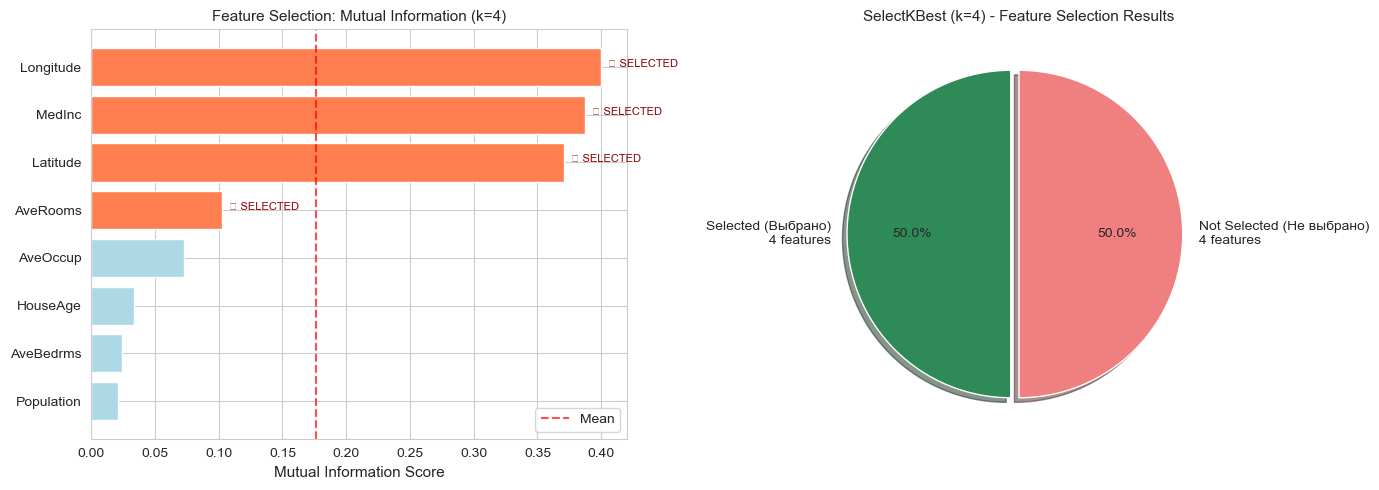


------------------------------------------------------------
【4.3】VARIANCE THRESHOLD (порог дисперсии = 0.01)
方差阈值法（threshold = 0.01）
------------------------------------------------------------
  Выбрано признаков / 选中特征数: 8
  Удалено признаков / 删除特征数: 0
  Удаленные признаки / 删除的特征: нет / 无

РЕЗУЛЬТАТЫ ФИЛЬТРАЦИОННОГО МЕТОДА
过滤法结果总结
  Метод / 方法: SelectKBest + Mutual Information
  Выбрано признаков / 选中特征数: 4
  Выбранные признаки / 选中的特征: ['MedInc', 'AveRooms', 'Latitude', 'Longitude']

  Рейтинг MI Score / 互信息得分排名:
    ✓ Longitude: 0.400147
    ✓ MedInc: 0.387097
    ✓ Latitude: 0.370763
    ✓ AveRooms: 0.102874
      AveOccup: 0.072716
      HouseAge: 0.033368
      AveBedrms: 0.024149
      Population: 0.020878

✓ TASK 4 COMPLETED / ЗАДАЧА 4 ВЫПОЛНЕНА!


In [11]:
# ============================================================================
# ЗАДАЧА 4: ОТБОР ПРИЗНАКОВ - ФИЛЬТРАЦИОННЫЙ МЕТОД (SelectKBest + Mutual Information)
# TASK 4: FEATURE SELECTION - FILTER METHOD (SelectKBest + Mutual Information)
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 4: ФИЛЬТРАЦИОННЫЙ МЕТОД ОТБОРА ПРИЗНАКОВ")
print("TASK 4: FILTER METHOD FOR FEATURE SELECTION")
print("=" * 60)

# Подготовка данных / 准备数据
# Используем только исходные числовые признаки (без временных)
# 只使用原始数值特征（不含时间特征）
original_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X = df[original_features].copy()
y = df['target'].copy()

print(f"\nИсходное количество признаков / 原始特征数量: {X.shape[1]}")
print(f"Признаки / 特征: {original_features}")

# ============================================================================
# 4.1 SelectKBest + Mutual Information (взаимная информация)
# SelectKBest + 互信息
# ============================================================================

print("\n" + "-" * 60)
print("【4.1】SELECTKBEST + MUTUAL INFORMATION (k=4)")
print("-" * 60)

from sklearn.feature_selection import SelectKBest, mutual_info_regression

selector_mi = SelectKBest(score_func=mutual_info_regression, k=4)
X_mi_selected = selector_mi.fit_transform(X, y)

selected_mi_features = X.columns[selector_mi.get_support()].tolist()
mi_scores = selector_mi.scores_

print(f"  Выбрано признаков / 选中特征数: {len(selected_mi_features)}")
print(f"\n  MI Scores для всех признаков / 所有特征的互信息得分:")

mi_df = pd.DataFrame({
    'Признак / Feature': X.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print(mi_df.to_string(index=False))

print(f"\n  ✓ Выбранные признаки (k=4) / 选中的特征:")
for i, feat in enumerate(selected_mi_features, 1):
    score = mi_scores[list(X.columns).index(feat)]
    print(f"    {i}. {feat} (MI Score: {score:.6f})")

# ============================================================================
# 4.2 Визуализация результатов фильтрационного метода
# 过滤法结果可视化
# ============================================================================

print("\n" + "-" * 60)
print("【4.2】ВИЗУАЛИЗАЦИЯ MI SCORES")
print("互信息得分可视化")
print("-" * 60)

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Горизонтальные столбцы MI Scores
    mi_df_sorted = mi_df.sort_values('MI Score', ascending=True)
    colors_mi = ['coral' if feat in selected_mi_features else 'lightblue' for feat in mi_df_sorted['Признак / Feature']]
    
    axes[0].barh(mi_df_sorted['Признак / Feature'], mi_df_sorted['MI Score'], color=colors_mi)
    axes[0].set_xlabel('Mutual Information Score', fontsize=11)
    axes[0].set_title('Feature Selection: Mutual Information (k=4)', fontsize=11)
    axes[0].axvline(x=mi_df_sorted['MI Score'].mean(), linestyle='--', color='red', alpha=0.7, label='Mean')
    axes[0].legend()
    
    # Отмечаем выбранные признаки
    for i, (_, row) in enumerate(mi_df_sorted.iterrows()):
        if row['Признак / Feature'] in selected_mi_features:
            axes[0].annotate('✓ SELECTED', xy=(row['MI Score'], row['Признак / Feature']),
                             xytext=(5, 0), textcoords='offset points', fontsize=8, color='darkred')
    
    # График 2: Круговая диаграмма
    sizes = [len(selected_mi_features), X.shape[1] - len(selected_mi_features)]
    labels = [f'Selected (Выбрано)\n{len(selected_mi_features)} features',
              f'Not Selected (Не выбрано)\n{X.shape[1] - len(selected_mi_features)} features']
    colors_pie = ['seagreen', 'lightcoral']
    explode = (0.05, 0)
    
    axes[1].pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                autopct='%1.1f%%', shadow=True, startangle=90)
    axes[1].set_title('SelectKBest (k=4) - Feature Selection Results', fontsize=11)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  Визуализация не удалась / 可视化失败: {e}")

# ============================================================================
# 4.3 Сравнение с Variance Threshold (дополнительный фильтрационный метод)
# 与方差阈值法比较（额外的过滤法）
# ============================================================================

print("\n" + "-" * 60)
print("【4.3】VARIANCE THRESHOLD (порог дисперсии = 0.01)")
print("方差阈值法（threshold = 0.01）")
print("-" * 60)

from sklearn.feature_selection import VarianceThreshold

selector_var = VarianceThreshold(threshold=0.01)
X_var_selected = selector_var.fit_transform(X)

selected_var_features = X.columns[selector_var.get_support()].tolist()
removed_var_features = X.columns[~selector_var.get_support()].tolist()

print(f"  Выбрано признаков / 选中特征数: {len(selected_var_features)}")
print(f"  Удалено признаков / 删除特征数: {len(removed_var_features)}")
if removed_var_features:
    print(f"  Удаленные признаки / 删除的特征: {removed_var_features}")
else:
    print(f"  Удаленные признаки / 删除的特征: нет / 无")

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ФИЛЬТРАЦИОННОГО МЕТОДА")
print("过滤法结果总结")
print("=" * 60)
print(f"  Метод / 方法: SelectKBest + Mutual Information")
print(f"  Выбрано признаков / 选中特征数: {len(selected_mi_features)}")
print(f"  Выбранные признаки / 选中的特征: {selected_mi_features}")
print(f"\n  Рейтинг MI Score / 互信息得分排名:")
for i, row in mi_df.iterrows():
    marker = "✓" if row['Признак / Feature'] in selected_mi_features else " "
    print(f"    {marker} {row['Признак / Feature']}: {row['MI Score']:.6f}")

print("\n✓ TASK 4 COMPLETED / ЗАДАЧА 4 ВЫПОЛНЕНА!")

ЗАДАЧА 5: МЕТОД ОБЁРТЫВАНИЯ (RFE - Recursive Feature Elimination)
TASK 5: WRAPPER METHOD (RFE - Recursive Feature Elimination)

Исходное количество признаков / Original features count: 8
Признаки / Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

------------------------------------------------------------
【5.1】RFE С ЛИНЕЙНОЙ РЕГРЕССИЕЙ (n_features_to_select=4)
RFE with Linear Regression (n_features_to_select=4)
------------------------------------------------------------
  Выбрано признаков / Selected features count: 4

  Ранжирование признаков / Feature ranking (1 = selected):
    [X] MedInc: rank 1
    [ ] HouseAge: rank 3
    [ ] AveRooms: rank 2
    [X] AveBedrms: rank 1
    [ ] Population: rank 5
    [ ] AveOccup: rank 4
    [X] Latitude: rank 1
    [X] Longitude: rank 1

  [X] SELECTED FEATURES / ВЫБРАННЫЕ ПРИЗНАКИ:
    1. MedInc
    2. AveBedrms
    3. Latitude
    4. Longitude

---------------------------------------

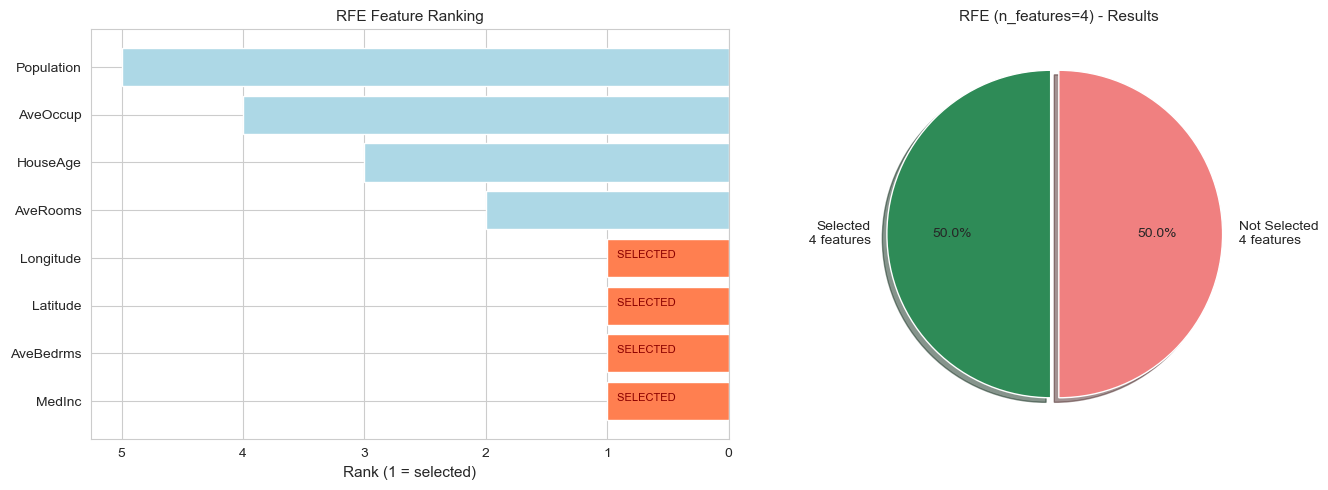


------------------------------------------------------------
【5.3】СРАВНЕНИЕ RFE ДЛЯ РАЗНОГО КОЛИЧЕСТВА ПРИЗНАКОВ
RFE comparison for different n_features
------------------------------------------------------------

  n_features = 3:
    Selected features / Выбранные признаки: ['MedInc', 'Latitude', 'Longitude']

  n_features = 4:
    Selected features / Выбранные признаки: ['MedInc', 'AveBedrms', 'Latitude', 'Longitude']

  n_features = 5:
    Selected features / Выбранные признаки: ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']

РЕЗУЛЬТАТЫ МЕТОДА ОБЁРТЫВАНИЯ / WRAPPER METHOD RESULTS
  Method: RFE (Recursive Feature Elimination) + Linear Regression
  Goal: select 4 features from 8
  Selected features: ['MedInc', 'AveBedrms', 'Latitude', 'Longitude']

  Feature ranking / Ранги признаков:
    MedInc: SELECTED
    HouseAge: rank 3
    AveRooms: rank 2
    AveBedrms: SELECTED
    Population: rank 5
    AveOccup: rank 4
    Latitude: SELECTED
    Longitude: SELECTED

✓ TASK 5

In [13]:
# ============================================================================
# ЗАДАЧА 5: МЕТОД ОБЁРТЫВАНИЯ (RFE - Recursive Feature Elimination)
# TASK 5: WRAPPER METHOD (RFE - Recursive Feature Elimination)
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 5: МЕТОД ОБЁРТЫВАНИЯ (RFE - Recursive Feature Elimination)")
print("TASK 5: WRAPPER METHOD (RFE - Recursive Feature Elimination)")
print("=" * 60)

# Подготовка данных / 准备数据
original_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X = df[original_features].copy()
y = df['target'].copy()

print(f"\nИсходное количество признаков / Original features count: {X.shape[1]}")
print(f"Признаки / Features: {original_features}")

# ============================================================================
# 5.1 RFE с линейной регрессией
# RFE with Linear Regression
# ============================================================================

print("\n" + "-" * 60)
print("【5.1】RFE С ЛИНЕЙНОЙ РЕГРЕССИЕЙ (n_features_to_select=4)")
print("RFE with Linear Regression (n_features_to_select=4)")
print("-" * 60)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=4)
rfe.fit(X, y)

selected_rfe_features = X.columns[rfe.support_].tolist()
rfe_ranking = rfe.ranking_

print(f"  Выбрано признаков / Selected features count: {len(selected_rfe_features)}")
print(f"\n  Ранжирование признаков / Feature ranking (1 = selected):")
for feat, rank in zip(X.columns, rfe_ranking):
    marker = "[X]" if rank == 1 else "[ ]"
    print(f"    {marker} {feat}: rank {rank}")

print(f"\n  [X] SELECTED FEATURES / ВЫБРАННЫЕ ПРИЗНАКИ:")
for i, feat in enumerate(selected_rfe_features, 1):
    print(f"    {i}. {feat}")

# ============================================================================
# 5.2 Visualization of RFE results (English + Russian only)
# Визуализация результатов RFE (только английский + русский)
# ============================================================================

print("\n" + "-" * 60)
print("【5.2】ВИЗУАЛИЗАЦИЯ / VISUALIZATION")
print("-" * 60)

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Feature ranking (График рангов признаков)
    rank_df = pd.DataFrame({'Feature': X.columns, 'Rank': rfe_ranking}).sort_values('Rank')
    colors_rank = ['coral' if rank == 1 else 'lightblue' for rank in rank_df['Rank']]
    
    axes[0].barh(rank_df['Feature'], rank_df['Rank'], color=colors_rank)
    axes[0].set_xlabel('Rank (1 = selected)', fontsize=11)
    axes[0].set_title('RFE Feature Ranking', fontsize=11)
    axes[0].invert_xaxis()
    
    # Add annotations
    for i, (_, row) in enumerate(rank_df.iterrows()):
        if row['Rank'] == 1:
            axes[0].annotate(' SELECTED', xy=(row['Rank'], row['Feature']),
                             xytext=(5, 0), textcoords='offset points', fontsize=8, color='darkred')
    
    # Plot 2: Pie chart (Круговая диаграмма)
    sizes = [len(selected_rfe_features), X.shape[1] - len(selected_rfe_features)]
    labels = [f'Selected\n{len(selected_rfe_features)} features',
              f'Not Selected\n{X.shape[1] - len(selected_rfe_features)} features']
    colors_pie = ['seagreen', 'lightcoral']
    explode = (0.05, 0)
    
    axes[1].pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                autopct='%1.1f%%', shadow=True, startangle=90)
    axes[1].set_title(f'RFE (n_features=4) - Results', fontsize=11)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  Visualization failed / Визуализация не удалась: {e}")

# ============================================================================
# 5.3 Comparison for different number of features
# Сравнение для разного количества признаков
# ============================================================================

print("\n" + "-" * 60)
print("【5.3】СРАВНЕНИЕ RFE ДЛЯ РАЗНОГО КОЛИЧЕСТВА ПРИЗНАКОВ")
print("RFE comparison for different n_features")
print("-" * 60)

for k in [3, 4, 5]:
    rfe_k = RFE(estimator=lr, n_features_to_select=k)
    rfe_k.fit(X, y)
    selected_k = X.columns[rfe_k.support_].tolist()
    print(f"\n  n_features = {k}:")
    print(f"    Selected features / Выбранные признаки: {selected_k}")

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ МЕТОДА ОБЁРТЫВАНИЯ / WRAPPER METHOD RESULTS")
print("=" * 60)
print(f"  Method: RFE (Recursive Feature Elimination) + Linear Regression")
print(f"  Goal: select {len(selected_rfe_features)} features from {X.shape[1]}")
print(f"  Selected features: {selected_rfe_features}")
print(f"\n  Feature ranking / Ранги признаков:")
for feat, rank in zip(X.columns, rfe_ranking):
    status = "SELECTED" if rank == 1 else f"rank {rank}"
    print(f"    {feat}: {status}")

print("\n✓ TASK 5 COMPLETED / ЗАДАЧА 5 ВЫПОЛНЕНА!")

ЗАДАЧА 6: ВЛОЖЕННЫЕ МЕТОДЫ ОТБОРА ПРИЗНАКОВ
TASK 6: EMBEDDED METHODS FOR FEATURE SELECTION

Исходное количество признаков / Original features count: 8
Признаки / Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

------------------------------------------------------------
【6.1】LASSO (L1-REGULARIZATION)
------------------------------------------------------------

  Coefficients (ненулевые / non-zero):
   Feature  Coefficient
    MedInc     0.399842
 AveBedrms     0.274245
  HouseAge     0.010119
Population    -0.000001
  AveOccup    -0.003636
  AveRooms    -0.036322
  Latitude    -0.409228
 Longitude    -0.416745

  [X] SELECTED FEATURES (Lasso) / ВЫБРАННЫЕ ПРИЗНАКИ (8):
    1. MedInc (coef: 0.399842)
    2. AveBedrms (coef: 0.274245)
    3. HouseAge (coef: 0.010119)
    4. Population (coef: -0.000001)
    5. AveOccup (coef: -0.003636)
    6. AveRooms (coef: -0.036322)
    7. Latitude (coef: -0.409228)
    8. Longitude (coef: 

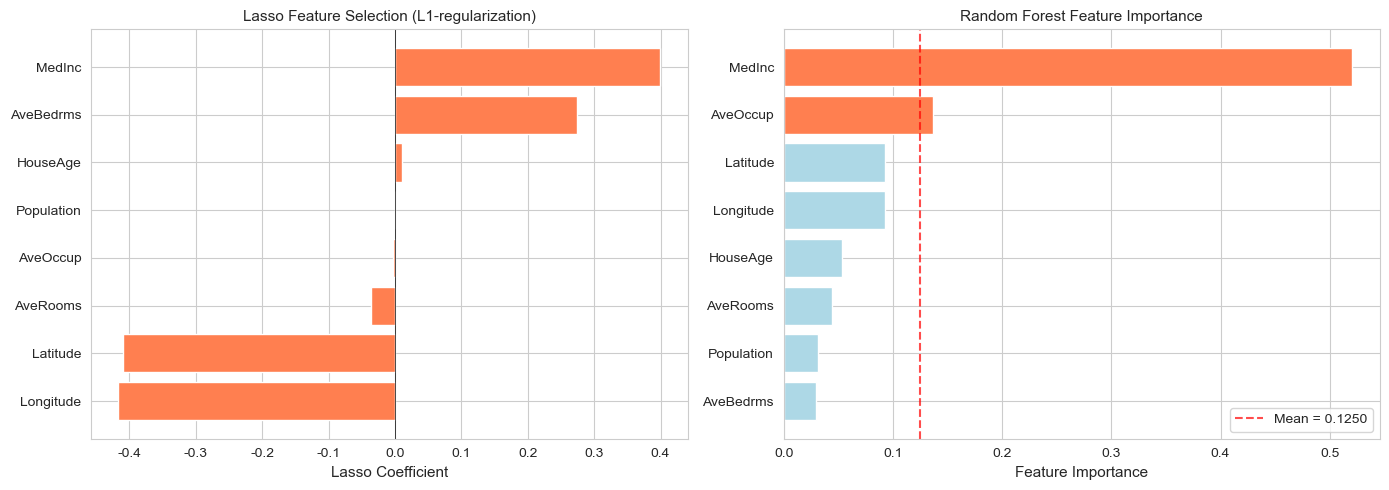


СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ
FEATURE SELECTION METHODS COMPARISON
                  Method  Selected Features Count                                                                Selected Features
    Filter (Mutual Info)                        4                                            MedInc, AveRooms, Latitude, Longitude
           Wrapper (RFE)                        4                                           MedInc, AveBedrms, Latitude, Longitude
        Embedded (Lasso)                        8 MedInc, AveBedrms, HouseAge, Population, AveOccup, AveRooms, Latitude, Longitude
Embedded (Random Forest)                        2                                                                 MedInc, AveOccup

ОБЩИЙ ИТОГ / FINAL SUMMARY
  ✓ TASK 1: Feature scaling (4 methods) - completed
  ✓ TASK 2: Outlier handling (deletion + clipping) - completed
  ✓ TASK 3: Non-standard feature (date/time processing) - completed
  ✓ TASK 4: Filter method (Mutual Information) - completed
  

In [15]:
# ============================================================================
# ЗАДАЧА 6: ОТБОР ПРИЗНАКОВ - ВЛОЖЕННЫЕ МЕТОДЫ (Lasso + Random Forest)
# TASK 6: FEATURE SELECTION - EMBEDDED METHODS (Lasso + Random Forest)
# ============================================================================

print("=" * 60)
print("ЗАДАЧА 6: ВЛОЖЕННЫЕ МЕТОДЫ ОТБОРА ПРИЗНАКОВ")
print("TASK 6: EMBEDDED METHODS FOR FEATURE SELECTION")
print("=" * 60)

# Подготовка данных / 准备数据
original_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X = df[original_features].copy()
y = df['target'].copy()

print(f"\nИсходное количество признаков / Original features count: {X.shape[1]}")
print(f"Признаки / Features: {original_features}")

# ============================================================================
# 6.1 Lasso (L1-регуляризация)
# Lasso (L1-regularization)
# ============================================================================

print("\n" + "-" * 60)
print("【6.1】LASSO (L1-REGULARIZATION)")
print("-" * 60)

from sklearn.linear_model import Lasso

# Создаем и обучаем модель Lasso / Create and train Lasso model
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X, y)

# Получаем коэффициенты / Get coefficients
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', ascending=False)

print("\n  Coefficients (ненулевые / non-zero):")
nonzero_coef = lasso_coef[lasso_coef['Coefficient'] != 0]
if len(nonzero_coef) > 0:
    print(nonzero_coef.to_string(index=False))
else:
    print("  Все коэффициенты равны нулю / All coefficients are zero")

# Выбираем признаки с ненулевыми коэффициентами / Select non-zero features
selected_lasso_features = lasso_coef[lasso_coef['Coefficient'] != 0]['Feature'].tolist()
print(f"\n  [X] SELECTED FEATURES (Lasso) / ВЫБРАННЫЕ ПРИЗНАКИ ({len(selected_lasso_features)}):")
for i, feat in enumerate(selected_lasso_features, 1):
    coef = lasso_coef[lasso_coef['Feature'] == feat]['Coefficient'].values[0]
    print(f"    {i}. {feat} (coef: {coef:.6f})")

# ============================================================================
# 6.2 Random Forest Feature Importance
# Случайный лес - важность признаков
# ============================================================================

print("\n" + "-" * 60)
print("【6.2】RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 60)

from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n  Feature Importance / Важность признаков:")
print(rf_importance.to_string(index=False))

# Select features with importance above mean
mean_importance = rf_importance['Importance'].mean()
selected_rf_features = rf_importance[rf_importance['Importance'] > mean_importance]['Feature'].tolist()

print(f"\n  Mean importance / Средняя важность: {mean_importance:.4f}")
print(f"\n  [X] SELECTED FEATURES (Random Forest) / ВЫБРАННЫЕ ПРИЗНАКИ ({len(selected_rf_features)}):")
for i, feat in enumerate(selected_rf_features, 1):
    imp = rf_importance[rf_importance['Feature'] == feat]['Importance'].values[0]
    print(f"    {i}. {feat} (importance: {imp:.4f})")

# ============================================================================
# 6.3 Visualization
# Визуализация
# ============================================================================

print("\n" + "-" * 60)
print("【6.3】ВИЗУАЛИЗАЦИЯ / VISUALIZATION")
print("-" * 60)

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Lasso coefficients
    lasso_pos = lasso_coef[lasso_coef['Coefficient'] != 0].sort_values('Coefficient')
    if len(lasso_pos) > 0:
        colors_lasso = ['coral' if abs(coef) > 0 else 'lightblue' for coef in lasso_pos['Coefficient']]
        axes[0].barh(lasso_pos['Feature'], lasso_pos['Coefficient'], color=colors_lasso)
        axes[0].set_xlabel('Lasso Coefficient', fontsize=11)
        axes[0].set_title('Lasso Feature Selection (L1-regularization)', fontsize=11)
        axes[0].axvline(x=0, linestyle='-', color='black', linewidth=0.5)
    else:
        axes[0].text(0.5, 0.5, 'No non-zero coefficients', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Lasso Feature Selection', fontsize=11)
    
    # Plot 2: Random Forest Feature Importance
    rf_sorted = rf_importance.sort_values('Importance')
    colors_rf = ['coral' if imp > mean_importance else 'lightblue' for imp in rf_sorted['Importance']]
    axes[1].barh(rf_sorted['Feature'], rf_sorted['Importance'], color=colors_rf)
    axes[1].set_xlabel('Feature Importance', fontsize=11)
    axes[1].set_title('Random Forest Feature Importance', fontsize=11)
    axes[1].axvline(x=mean_importance, linestyle='--', color='red', alpha=0.7, label=f'Mean = {mean_importance:.4f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  Visualization failed / Визуализация не удалась: {e}")

# ============================================================================
# 6.4 Comparison of all feature selection methods
# Сравнение всех методов отбора признаков
# ============================================================================

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ")
print("FEATURE SELECTION METHODS COMPARISON")
print("=" * 60)

comparison_methods = pd.DataFrame({
    'Method': ['Filter (Mutual Info)', 'Wrapper (RFE)', 'Embedded (Lasso)', 'Embedded (Random Forest)'],
    'Selected Features Count': [
        len(selected_mi_features),
        len(selected_rfe_features),
        len(selected_lasso_features),
        len(selected_rf_features)
    ],
    'Selected Features': [
        ', '.join(selected_mi_features),
        ', '.join(selected_rfe_features),
        ', '.join(selected_lasso_features) if selected_lasso_features else 'None',
        ', '.join(selected_rf_features)
    ]
})

print(comparison_methods.to_string(index=False))

# ============================================================================
# Final Summary
# Итоговый вывод
# ============================================================================

print("\n" + "=" * 60)
print("ОБЩИЙ ИТОГ / FINAL SUMMARY")
print("=" * 60)
print("  ✓ TASK 1: Feature scaling (4 methods) - completed")
print("  ✓ TASK 2: Outlier handling (deletion + clipping) - completed")
print("  ✓ TASK 3: Non-standard feature (date/time processing) - completed")
print("  ✓ TASK 4: Filter method (Mutual Information) - completed")
print("  ✓ TASK 5: Wrapper method (RFE) - completed")
print("  ✓ TASK 6: Embedded methods (Lasso + Random Forest) - completed")

print("\n" + "-" * 40)
print("FEATURE SELECTION RESULTS SUMMARY")
print("РЕЗУЛЬТАТЫ ОТБОРА ПРИЗНАКОВ")
print("-" * 40)
print(f"  Filter (Mutual Info)     : {selected_mi_features}")
print(f"  Wrapper (RFE)            : {selected_rfe_features}")
print(f"  Embedded (Lasso)         : {selected_lasso_features if selected_lasso_features else 'None (alpha may be too high)'}")
print(f"  Embedded (Random Forest) : {selected_rf_features}")

